In [42]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler
import joblib

In [43]:
print("Generating environmental dataset")
np.random.seed(42)
timesteps = 4000

Generating environmental dataset


In [44]:
time_axis = np.linspace(0, 150, timesteps)
traffic_seq = 50 + 35 * np.sin(time_axis) + np.random.uniform(-7, 7, timesteps)
wind_seq = 15 + 10 * np.cos(time_axis * 0.5) + np.random.uniform(-3, 3, timesteps)
factory_seq = 60 + 20 * np.sin(time_axis * 1.2) + np.random.uniform(-12, 12, timesteps)
temp_seq = 28 + 8 * np.sin(time_axis - 1.5) + np.random.uniform(-2, 2, timesteps)

In [45]:
##physical dynamics equation
base_aqi=(traffic_seq*1.4)+(factory_seq*1.1)-(wind_seq*1.6)+(temp_seq*0.3)+30

In [46]:
##real worrld ki sensor pluctuation ke liye hai (gaussian noise)
target_aqi = np.clip(base_aqi + np.random.normal(0, 6, timesteps), 15, 500)

In [47]:
#now changee to datframe
df = pd.DataFrame({
    'traffic_density': traffic_seq,
    'wind_speed': wind_seq,
    'factory_emissions': factory_seq,
    'temperature': temp_seq,
    'aqi': target_aqi
})

DATA PREPROCESSING

In [48]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [49]:
def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])
        y.append(data[i + window_size, 4])
    return np.array(X), np.array(y)

WINDOW_SIZE = 24
X, y = create_sequences(scaled_data, WINDOW_SIZE)

split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

BIDIRECTIONAL LSTM RNN MODEL TRAINING

In [ ]:
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(WINDOW_SIZE, 5)),
    Dropout(0.1),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.1),

    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
##usign adam optimizer -loss function ke liye
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=opt, loss='mean_squared_error', metrics=['mae'])

In [52]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=26,
    restore_best_weights=True,
    verbose=1
)

In [53]:
##main training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0237 - mae: 0.1100 - val_loss: 0.0056 - val_mae: 0.0601
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0059 - mae: 0.0613 - val_loss: 0.0043 - val_mae: 0.0522
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0049 - mae: 0.0557 - val_loss: 0.0038 - val_mae: 0.0498
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046 - mae: 0.0547 - val_loss: 0.0038 - val_mae: 0.0494
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0046 - mae: 0.0543 - val_loss: 0.0043 - val_mae: 0.0524
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0044 - mae: 0.0536 - val_loss: 0.0038 - val_mae: 0.0493
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0044 - mae: 0.0534 - val_loss: 0.0042 - val_mae: 0.0515
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0044 - mae: 0.0533 - val_loss: 0.0039 - val_mae: 0.0503
Epoch 9/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.004

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
 Validation R² Score: 91.94%


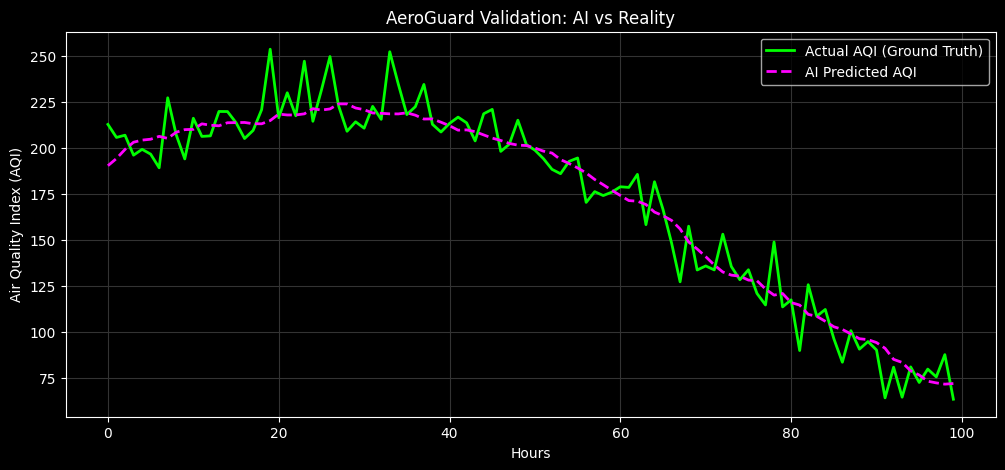

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
##getting the predcition of model
raw_predictions = model.predict(X_val)

pred_1d = raw_predictions.flatten()
if len(y_val.shape) > 1 and y_val.shape[1] > 1:
    actual_1d = y_val[:, -1]
else:
    actual_1d = y_val.flatten()
dummy_pred = np.zeros((len(pred_1d), 5))
dummy_pred[:, 4] = pred_1d
unscaled_predictions = scaler.inverse_transform(dummy_pred)[:, 4]

dummy_actual = np.zeros((len(actual_1d), 5))
dummy_actual[:, 4] = actual_1d
unscaled_actual = scaler.inverse_transform(dummy_actual)[:, 4]

# 4. Calculate Error Metrics
mae = mean_absolute_error(unscaled_actual, unscaled_predictions)
r2 = r2_score(unscaled_actual, unscaled_predictions)
print(f" Validation R² Score: {r2 * 100:.2f}%")
# 5. Plot the Graph
plt.style.use('dark_background')
plt.figure(figsize=(12,5))
plt.plot(unscaled_actual[:100], label="Actual AQI (Ground Truth)", color="#00FF00", linewidth=2)
plt.plot(unscaled_predictions[:100], label="AI Predicted AQI",color="#FF00FF",linestyle="dashed",linewidth=2)
plt.title("AeroGuard Validation: AI vs Reality")
plt.xlabel("Hours")
plt.ylabel("Air Quality Index (AQI)")
plt.legend()
plt.grid(color='#333333')
plt.show()

In [60]:
joblib.dump(scaler, 'aqi_pipeline_scaler.pkl')

['aqi_pipeline_scaler.pkl']